# Ejercicio Formativo 2 Capitulo 2

## Importando librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Misión 0

"Para cumplir las misiones de este taller, es fundamental explorar inicialmente el contenido del archivo
y familiarizarse con el formato en que está almacenada la información. Para eso, utilice los comandos
`describe` y `head` de pandas."

In [2]:
df = pd.read_csv("E2_data.csv")
df.head(10)

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,2008,1,1,29.63,NaN,NaN
1,2008,1,2,21.46,NaN,NaN
2,2008,1,3,24.25,NaN,NaN
3,2008,1,4,29.04,NaN,NaN
4,2008,1,5,30.17,NaN,NaN
5,2008,1,6,29.50,NaN,NaN
6,2008,1,7,26.79,NaN,NaN
7,2008,1,8,25.29,NaN,NaN
8,2008,1,9,14.62,NaN,NaN
9,2008,1,10,18.17,NaN,NaN


In [3]:
df.dtypes

,0
Year,int64
Month,int64
Day,int64
O3,float64
PM2.5,float64
Environmental_risk,object


In [4]:
df.describe()

,Year,Month,Day,O3,PM2.5
count,2984.000000,2984.000000,2984.000000,2878.000000,2725.000000
mean,2011.592493,6.419236,15.715818,16.313767,28.814594
std,2.357040,3.487660,8.804066,7.995680,17.479388
min,2008.000000,1.000000,1.000000,1.000000,5.000000
25%,2010.000000,3.000000,8.000000,9.392500,16.170000
50%,2012.000000,6.000000,16.000000,16.960000,23.210000
75%,2014.000000,9.000000,23.000000,22.357500,37.210000
max,2016.000000,12.000000,31.000000,56.300000,126.200000


Funciones:

*   `tail`: muestra las **n** ultimas filas.
*   `value_counts`: devuelve los distintos valores incluidos en la serie junto con el número de apariciones de cada uno.



In [12]:
enviromental_risk = df['Environmental_risk']
enviromental_risk.tail()

,Environmental_risk
2979,Bajo
2980,Bajo
2981,Bajo
2982,medio
2983,medio


In [14]:
enviromental_risk.value_counts()

,count
Environmental_risk,
medio,1605
Bajo,750
nulo,134
Alto,106
extremo,61


## Misión 1

"Tanto para O3 como para PM2.5, el conjunto contiene datos incompletos para algunos días, que fueron
generados por motivos desconocidos. Con el fin de facilitar el análisis futuro, debeía ajustar los datos
faltantes de 2 formas distintas. Para esto último, cree 2 nuevos `DataFrame`, en el primero de ellos complete
los datos faltantes con la media, y en el segundo elimínelos."


Se crean copias de los dataframes para no modificar el original y ejecutar las correcciones en las copias. El dataframe `df_media` tendrá el método en el cual los valores nulos se reemplazan por la media mientras que `df_null` tendrá el método en el cual se eliminan los valores nulos.

Funciones:

*   `copy`: crea una copia de un DataFrame o una Serie.
*   `fillna`: permite reemplazar valores faltantes (NaN) en un DataFrame o serie.
*   `dropna`: elimina filas o columnas que contienen valores nulos (NaN).



In [15]:
df_media = df.copy()
df_null = df.copy()

In [16]:
media_03 = df_media['O3'].mean()
media_pm25 = df_media['PM2.5'].mean()

In [17]:
df_media['O3'] = df_media['O3'].fillna(media_03)
df_media['PM2.5'] = df_media['PM2.5'].fillna(media_pm25)
df_media.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,2008,1,1,29.63,28.814594,NaN
1,2008,1,2,21.46,28.814594,NaN
2,2008,1,3,24.25,28.814594,NaN
3,2008,1,4,29.04,28.814594,NaN
4,2008,1,5,30.17,28.814594,NaN


In [18]:
df_null = df_null.dropna(subset=['O3', 'PM2.5'])
df_null.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
127,2008,5,7,8.46,48.53,medio
128,2008,5,8,12.96,56.57,medio
129,2008,5,9,12.00,54.00,medio
130,2008,5,10,15.33,69.40,medio
131,2008,5,11,18.12,91.08,medio


## Misión 2

"A continuación, para ambos `DataFrame` generados en el ítem anterior y de manera independiente, imprima
en una tabla ordenada los siguientes indicadores para O3 y PM2.5: media, desviación estándar, máximo,
mínimo, Kurtosis. Además, agregue a esta tabla la correlación entre O3 y PM2.5."

### Tabla Media

In [19]:
media_O3 = df_media['O3'].mean()
std_O3 = df_media['O3'].std()
max_O3 = df_media['O3'].max()
min_O3 = df_media['O3'].min()
kurtosis_O3 = df_media['O3'].kurtosis()

media_pm25 = df_media['PM2.5'].mean()
std_pm25 = df_media['PM2.5'].std()
max_pm25 = df_media['PM2.5'].max()
min_pm25 = df_media['PM2.5'].min()
kurtosis_pm25 = df_media['PM2.5'].kurtosis()

corr_O3_pm25 = df_media['O3'].corr(df_media['PM2.5'])

tabla_nueva = pd.DataFrame({"Indicadores": ['Media', 'Desviación estándar', 'Máximo', 'Mínimo', 'Curtosis', 'Correlación O3-PM2.5'],
                           "03": [media_O3, std_O3, max_O3, min_O3, kurtosis_O3, corr_O3_pm25 ],
                           "PM2.5": [media_pm25, std_pm25, max_pm25, min_pm25, kurtosis_pm25, corr_O3_pm25]})
tabla_nueva.head()

,Indicadores,03,PM2.5
0,Media,16.313767,28.814594
1,Desviación estándar,7.852333,16.703334
2,Máximo,56.300000,126.200000
3,Mínimo,1.000000,5.000000
4,Curtosis,-0.225798,2.508613


### Tabla Null

In [20]:
media_O3 = df_null['O3'].mean()
std_O3 = df_null['O3'].std()
max_O3 = df_null['O3'].max()
min_O3 = df_null['O3'].min()
kurtosis_O3 = df_null['O3'].kurtosis()

media_pm25 = df_null['PM2.5'].mean()
std_pm25 = df_null['PM2.5'].std()
max_pm25 = df_null['PM2.5'].max()
min_pm25 = df_null['PM2.5'].min()
kurtosis_pm25 = df_null['PM2.5'].kurtosis()

corr_O3_pm25 = df_null['O3'].corr(df_null['PM2.5'])

tabla_nueva = pd.DataFrame({"Indicadores": ['Media', 'Desviación estándar', 'Máximo', 'Mínimo', 'Curtosis', 'Correlación O3-PM2.5'],
                            "O3": [media_O3, std_O3, max_O3, min_O3, kurtosis_O3, corr_O3_pm25 ],
                           "PM2.5": [media_pm25, std_pm25, max_pm25, min_pm25, kurtosis_pm25, corr_O3_pm25]})
tabla_nueva.head()

,Indicadores,O3,PM2.5
0,Media,15.961303,28.986977
1,Desviación estándar,8.042349,17.596844
2,Máximo,56.300000,126.200000
3,Mínimo,1.000000,5.000000
4,Curtosis,-0.263541,1.958536


## Misión 3

"Para ambos DataFrame obtenidos en el primer ítem y de manera independiente, genere las siguientes visualizaciones:
* Histograma de PM2.5
* Boxplot de O3 por mes
* Evolución promedio de O3 y PM2.5 por año."

Funciones:

*   `hist`: es una herramienta que permite crear histogramas de datos en un DataFrame.
*   `boxplot`:genera diagramas de caja.
*   `plot`: permite trazar líneas en un gráfico.



### Visualizaciones Tabla Media

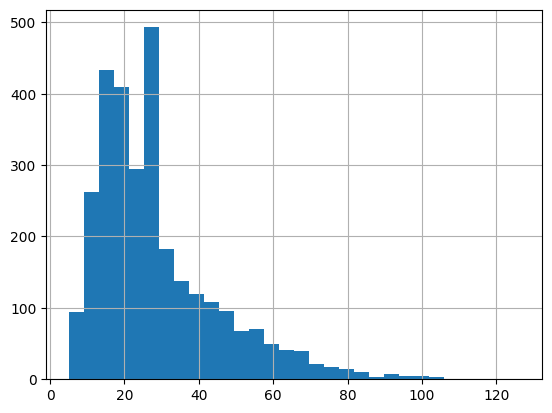

In [21]:
df_media['PM2.5'].hist(bins=30)
plt.show()

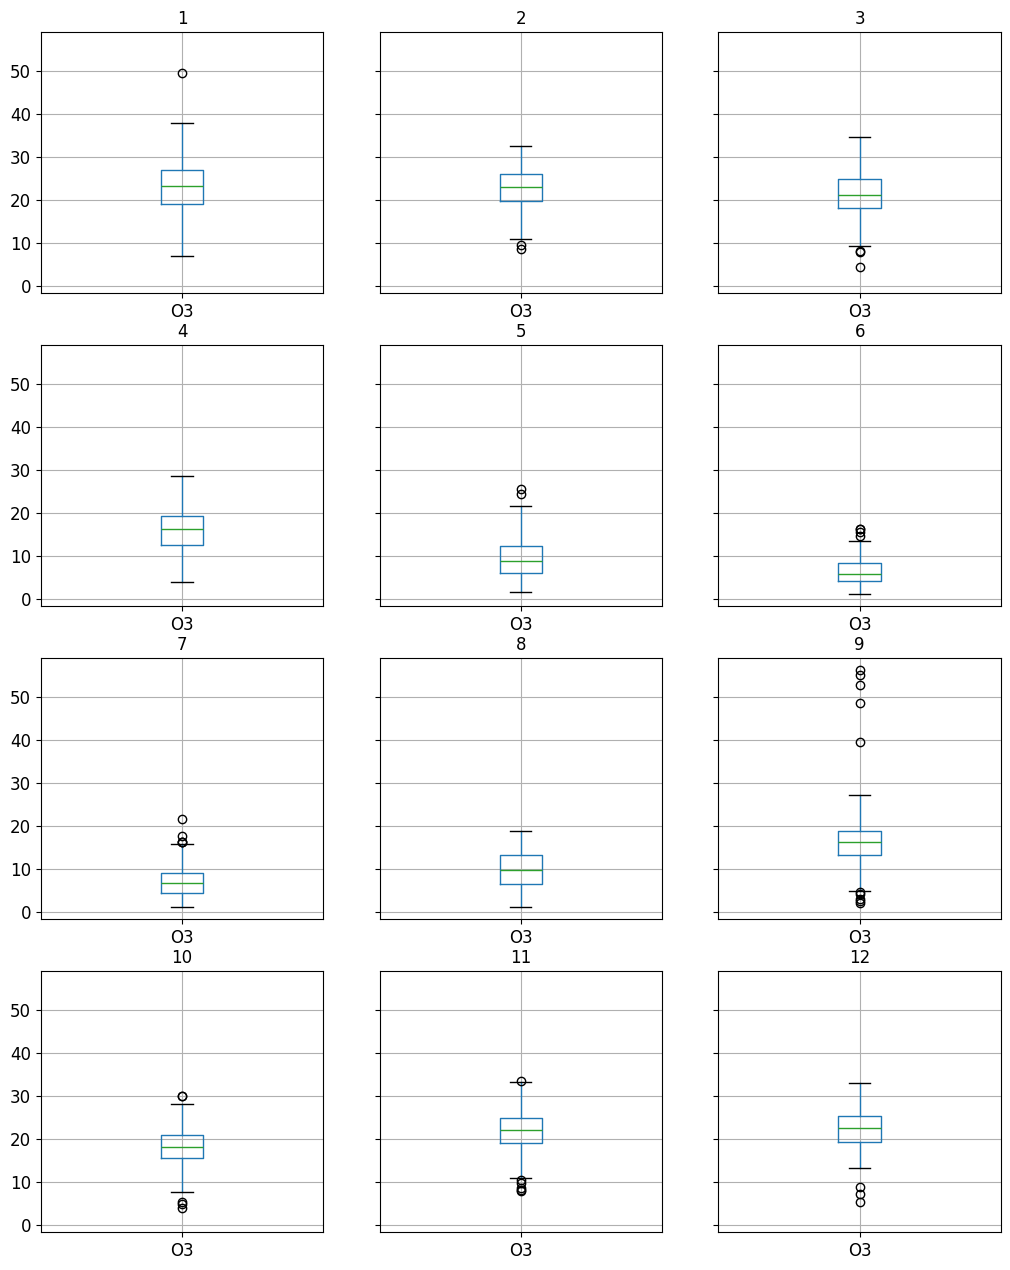

In [22]:
df_media.groupby('Month').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

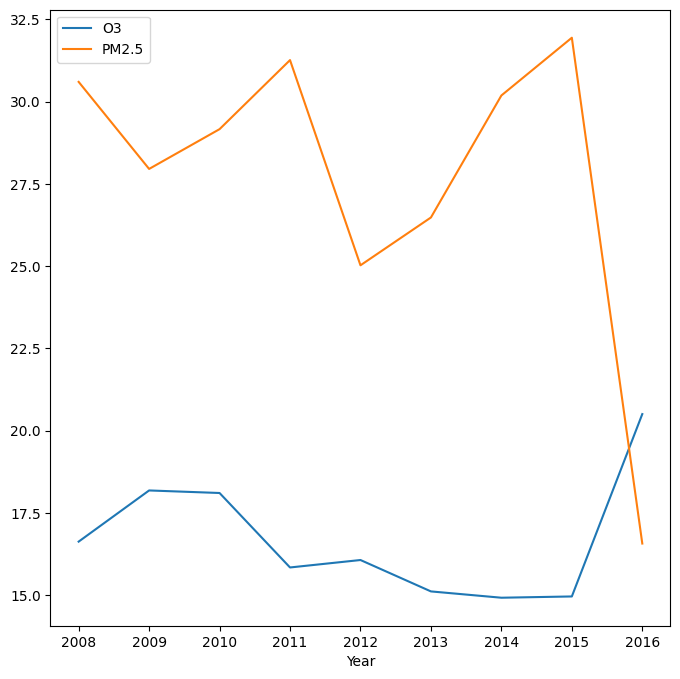

In [23]:
df_media.groupby('Year')[['O3', 'PM2.5']].mean().plot(figsize=(8, 8))
plt.show()

### Visualizaciones Tabla Null

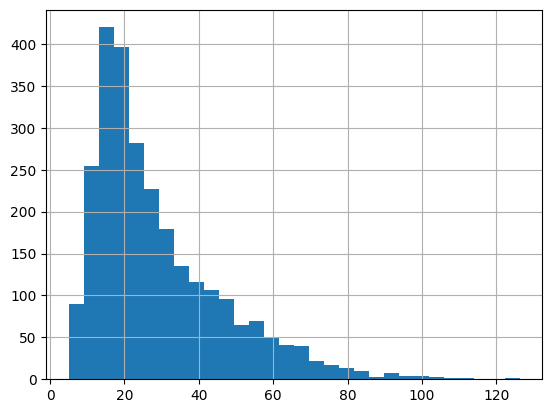

In [24]:
df_null['PM2.5'].hist(bins=30)
plt.show()

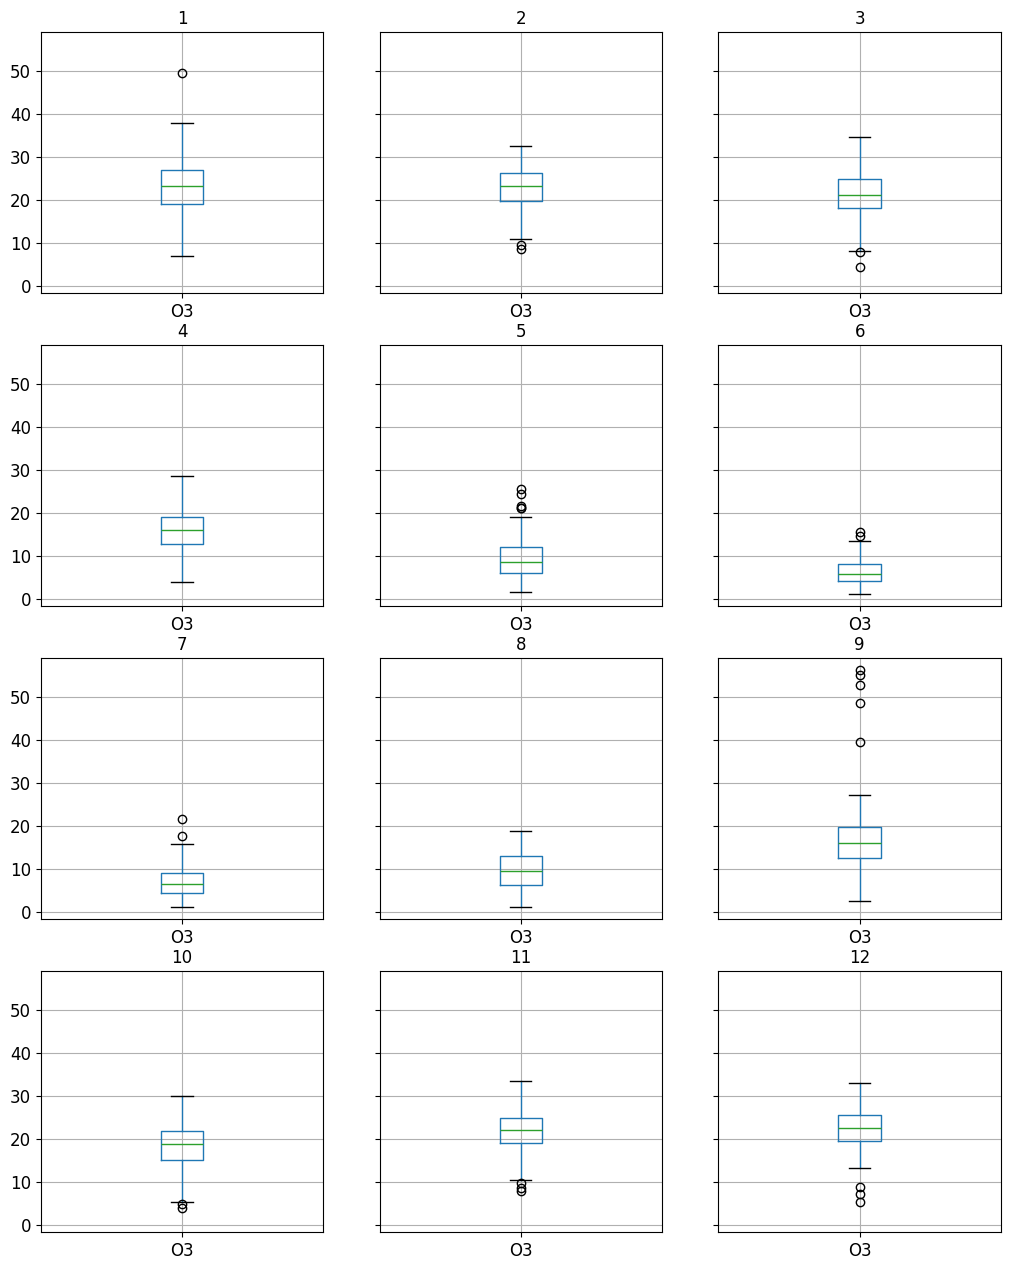

In [25]:
df_null.groupby('Month').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

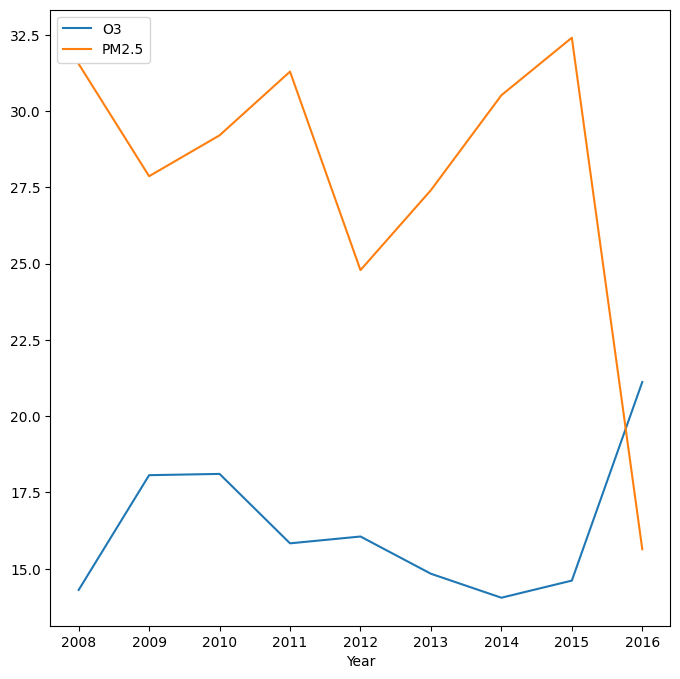

In [26]:
df_null.groupby('Year')[['O3', 'PM2.5']].mean().plot.line(figsize=(8, 8))
plt.show()

## Misión 4

"En base a todos los análisis realizados anteriormente, proponga e implemente en Python un esquema para
asignar un nivel de riesgo medioambiental para cada registro que no tiene esta información. Complete esto
para ambos DataFrame de manera independiente. Comente y analice los resultados."

Funciones:

*   `isna` o `isnull`: detecta los valores faltantes en un DataFrame o Serie.


In [27]:
def determinar_categoria(fila, media_O3, std_O3, media_PM25, std_PM25):
    if pd.isnull(fila['Environmental_risk']):
        if fila['O3'] > media_O3:
            if fila['O3'] > media_O3 + 2 * std_O3:
                return 'extremo'
            else:
                if fila['PM2.5'] > media_PM25:
                    if fila['PM2.5'] > media_PM25 + 2 * std_PM25:
                        return 'extremo'
                    else:
                        return 'Alto'
                else:
                    return 'medio'
        else:
            return 'Bajo'
    else:
        return fila['Environmental_risk']

### Tabla Media

In [28]:
df_media['Environmental_risk'].isna().value_counts()

,count
Environmental_risk,
False,2656
True,328


In [29]:
media_O3 = df_media['O3'].mean()
std_O3 = df_media['O3'].std()
media_PM25 = df_media['PM2.5'].mean()
std_PM25 = df_media['PM2.5'].std()
df_media['Environmental_risk'] = df_media.apply(determinar_categoria, args=(media_O3, std_O3, media_PM25, std_PM25), axis=1)

In [30]:
df_media['Environmental_risk'].isna().value_counts()

,count
Environmental_risk,
False,2984


### Tabla Null

In [31]:
df_null['Environmental_risk'].isnull().value_counts()

,count
Environmental_risk,
False,2656


## Misión 5

"Identifique patrones estacionales en los datos, utilizando el archivo data E2.csv para crear una nueva
columna que indique la estación del año (primavera, verano, otoño, invierno) para cada registro basado en la
fecha. Calcule la media de O3 y PM2.5 para cada estación y cada año y finalmente genere una visualización
que muestre la evolución de las medias estacionales de O3 y PM2.5 a lo largo del tiempo."

In [32]:
def asignar_estacion(mes):
    if mes in [1, 2, 12]:
        return 'Verano'
    elif mes in [4, 5, 3]:
        return 'Otoño'
    elif mes in [7, 8, 6]:
        return 'Invierno'
    else:
        return 'Primavera'

### Tabla Media

In [33]:
df_media['Estacion'] = df_media['Month'].apply(asignar_estacion)
df_media.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion
0,2008,1,1,29.63,28.814594,medio,Verano
1,2008,1,2,21.46,28.814594,medio,Verano
2,2008,1,3,24.25,28.814594,medio,Verano
3,2008,1,4,29.04,28.814594,medio,Verano
4,2008,1,5,30.17,28.814594,medio,Verano


In [34]:
df_media.groupby(['Estacion', 'Year'])[['O3', 'PM2.5']].mean()

O3      PM2.5
Estacion  Year                      
Invierno  2008   7.083370  43.558370
          2009  10.351604  41.451898
          2010  10.665884  42.472048
          2011   7.160217  42.559674
          2012   8.296971  37.209565
          2013   8.009239  40.076087
          2014   4.991522  46.632523
          2015   5.297813  53.395752
Otoño     2008  15.798587  33.800085
          2009  16.968804  31.478913
          2010  18.681753  34.292958
          2011  14.494891  32.716196
          2012  15.714173  29.512609
          2013  12.928913  28.063854
          2014  14.828913  28.313578
          2015  15.211848  36.682306
          2016  28.820000  30.315000
Primavera 2008  18.942747  19.676044
          2009  19.633077  18.536154
          2010  19.066141  19.819982
          2011  20.447912  25.956974
          2012  20.115714  15.718132
          2013  18.195104  20.876576
          2014  16.921704  25.022593
          2015  16.358684  20.443843
Verano    2008  24.787692  25.184568
          2009  25.950444  20.071417
          2010  24.137417  19.756991
          2011  21.423834  23.587093
          2012  20.223187  17.470220
          2013  21.482778  16.617444
          2014  23.134889  20.507270
          2015  23.155709  16.788547
          2016  20.224002  16.107640

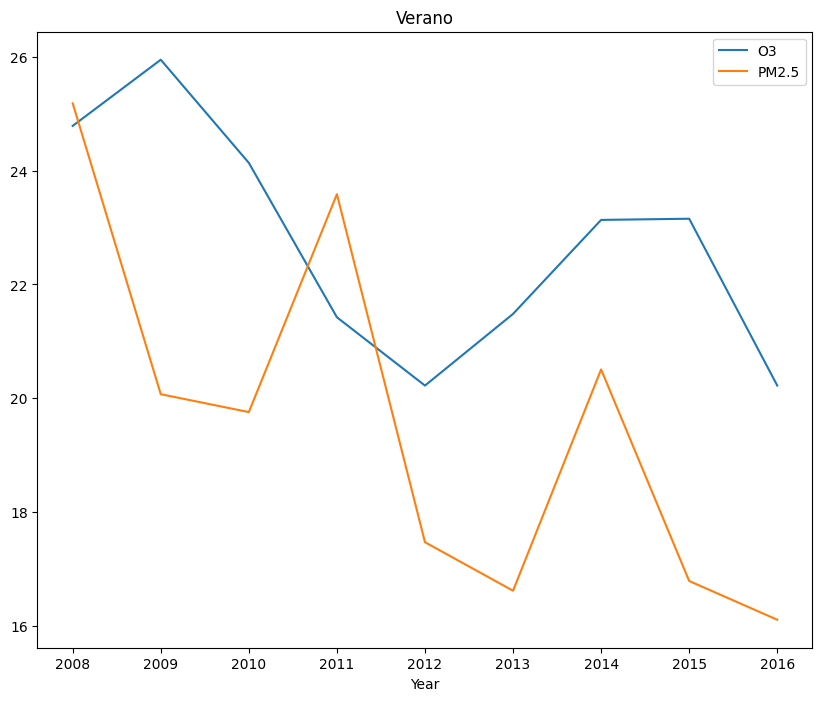

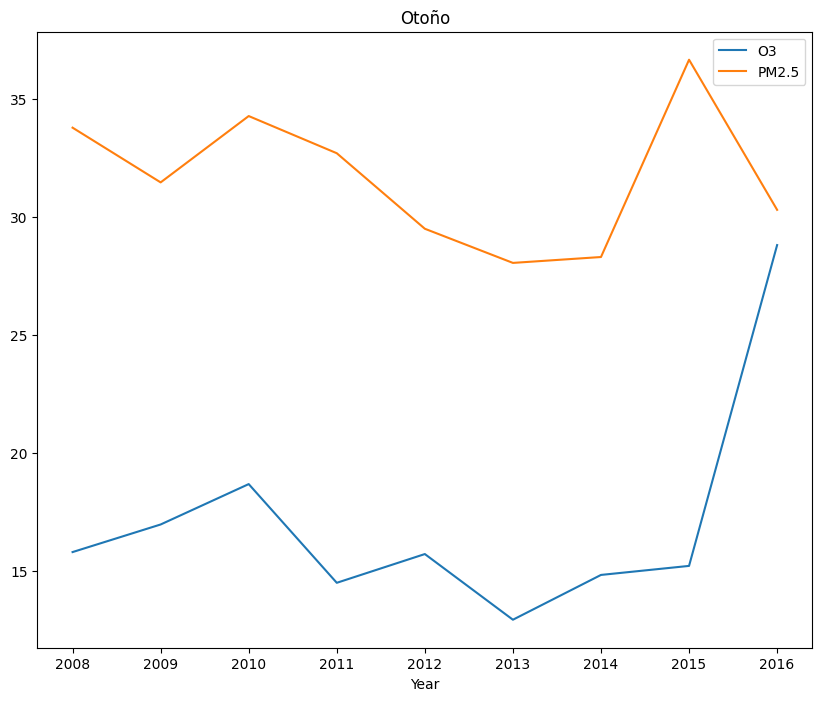

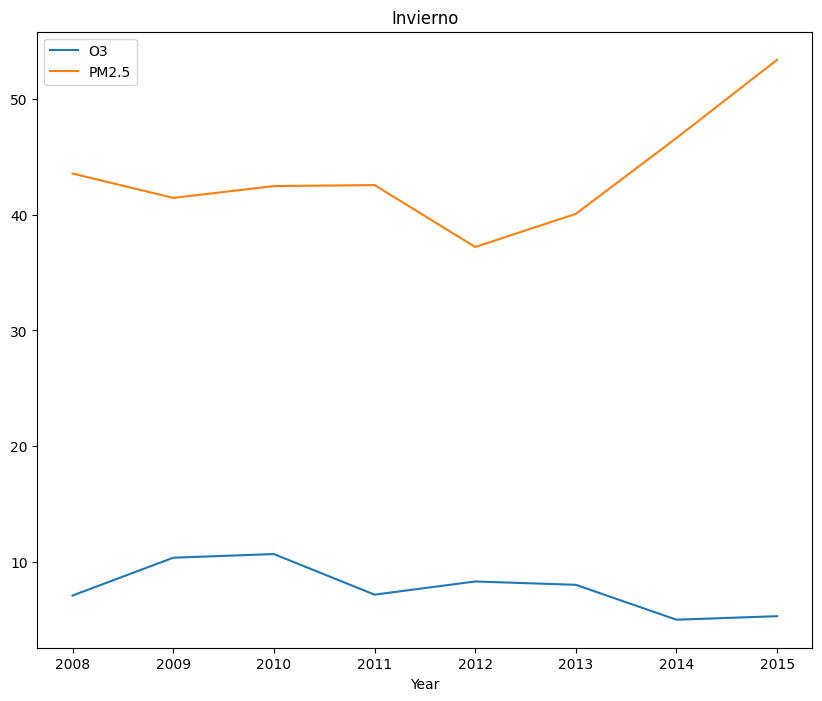

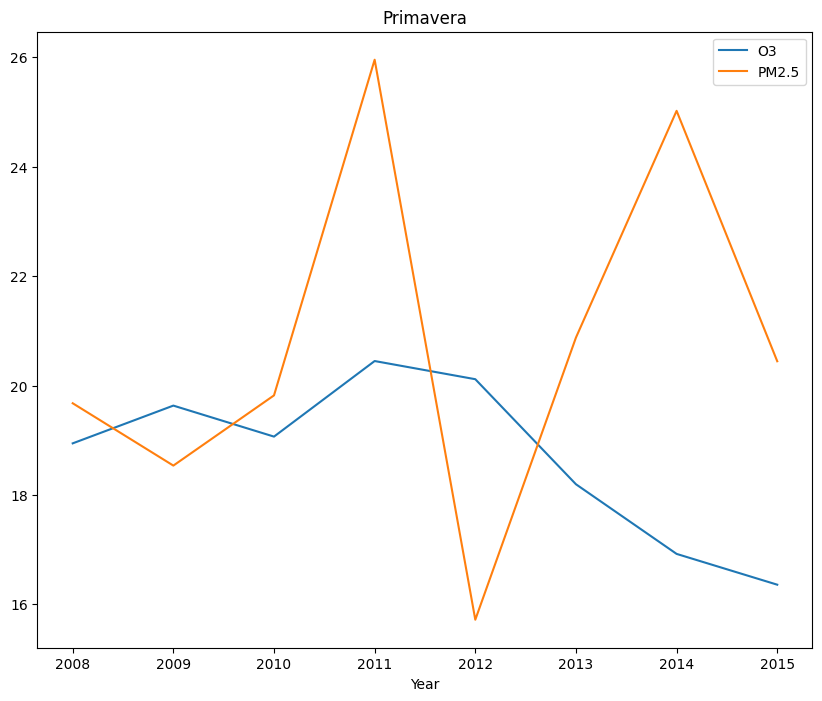

In [35]:
for value in pd.unique(df_media['Estacion'].values):
    sub_df = df_media[df_media['Estacion'] == value]
    sub_df.groupby("Year")[["O3", "PM2.5"]].mean().plot.line(figsize=(10, 8))
    plt.title(value)
    plt.show()

### Tabla Null

In [36]:
df_null['Estacion'] = df_null['Month'].apply(asignar_estacion)
df_null.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion
127,2008,5,7,8.46,48.53,medio,Otoño
128,2008,5,8,12.96,56.57,medio,Otoño
129,2008,5,9,12.00,54.00,medio,Otoño
130,2008,5,10,15.33,69.40,medio,Otoño
131,2008,5,11,18.12,91.08,medio,Otoño


In [37]:
df_null.groupby(['Estacion', 'Year'])[['O3', 'PM2.5']].mean()

O3      PM2.5
Estacion  Year                      
Invierno  2008   7.083370  43.558370
          2009  10.219111  41.465222
          2010  10.490341  43.092841
          2011   7.160217  42.559674
          2012   8.026742  37.200899
          2013   8.009239  40.076087
          2014   4.926941  48.099882
          2015   4.664713  55.456207
Otoño     2008   8.758400  47.161200
          2009  16.968804  31.478913
          2010  18.440118  34.744118
          2011  14.494891  32.716196
          2012  15.649157  29.446265
          2013  12.877802  28.055604
          2014  14.799667  28.302444
          2015  14.296118  37.330235
          2016  28.820000  30.315000
Primavera 2008  18.942747  19.676044
          2009  19.633077  18.536154
          2010  19.226163  19.402442
          2011  20.496889  25.925222
          2012  20.115714  15.718132
          2013  19.356739  21.914565
          2014  13.961250  20.083750
          2015  16.368267  18.731333
Verano    2008  26.594516  18.158710
          2009  25.981905  19.446905
          2010  24.315227  19.551136
          2011  21.661512  23.343953
          2012  20.223187  17.470220
          2013  21.482778  16.617444
          2014  23.413553  18.976974
          2015  23.253182  16.515227
          2016  20.825577  15.075000

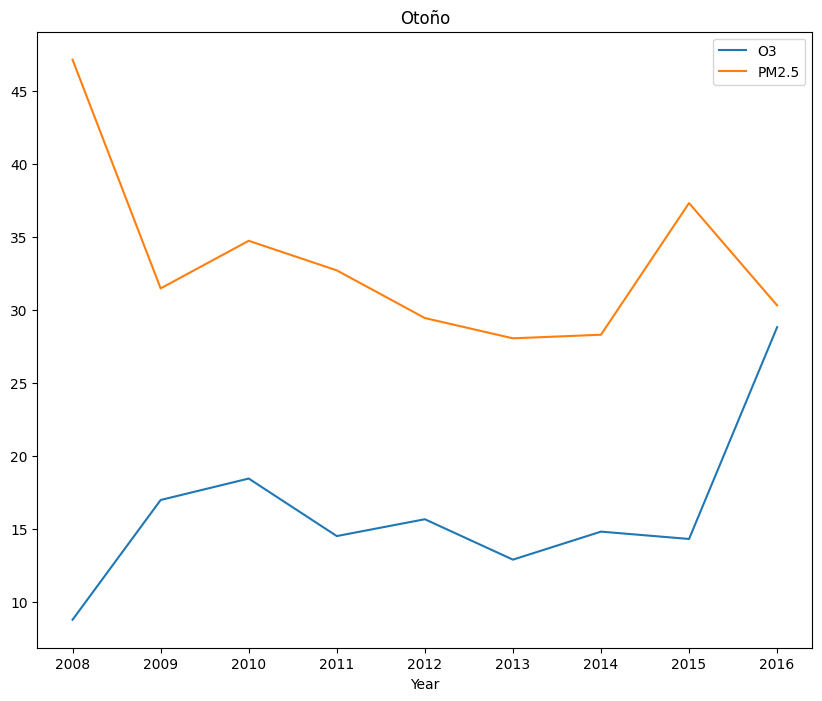

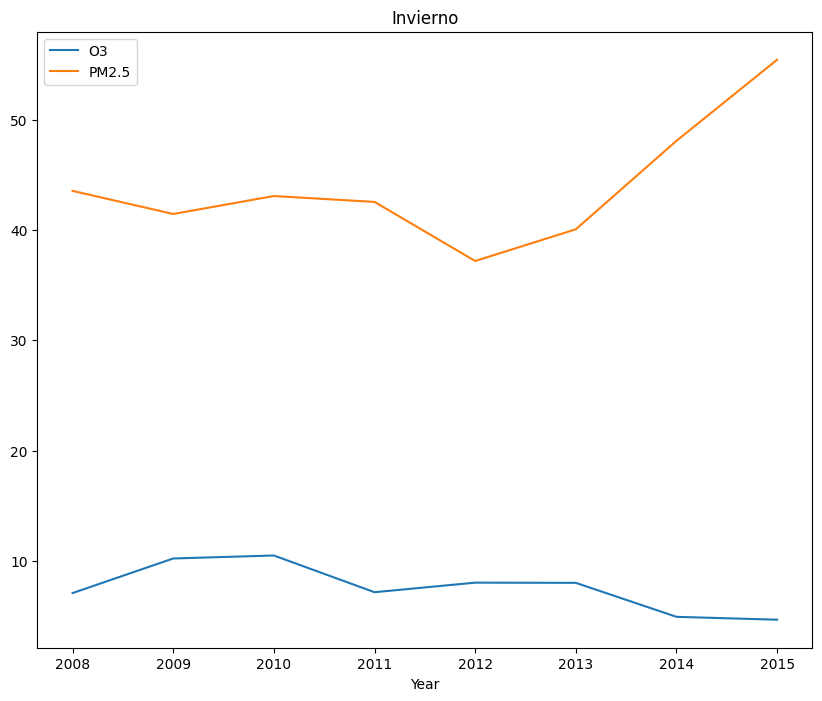

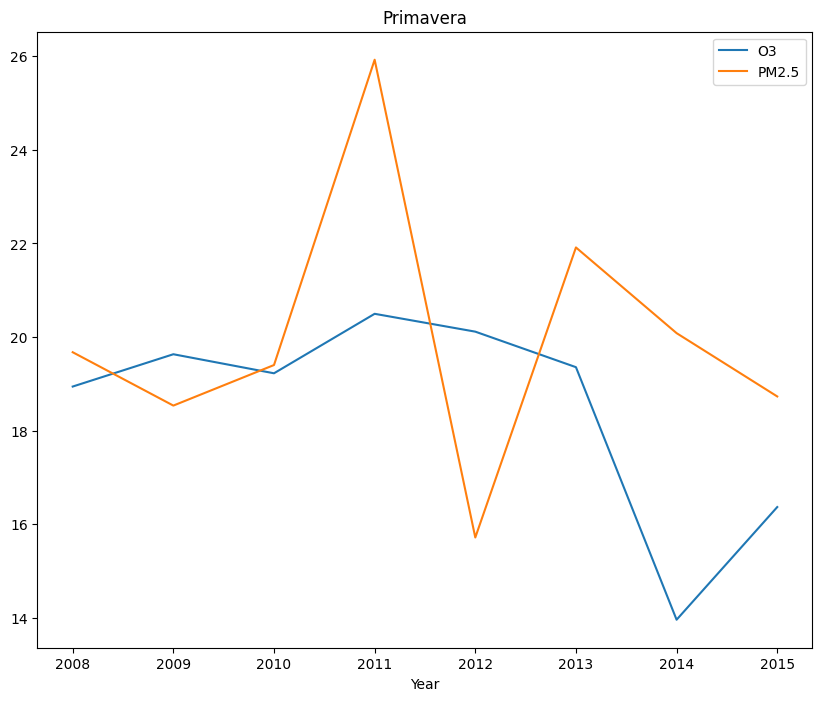

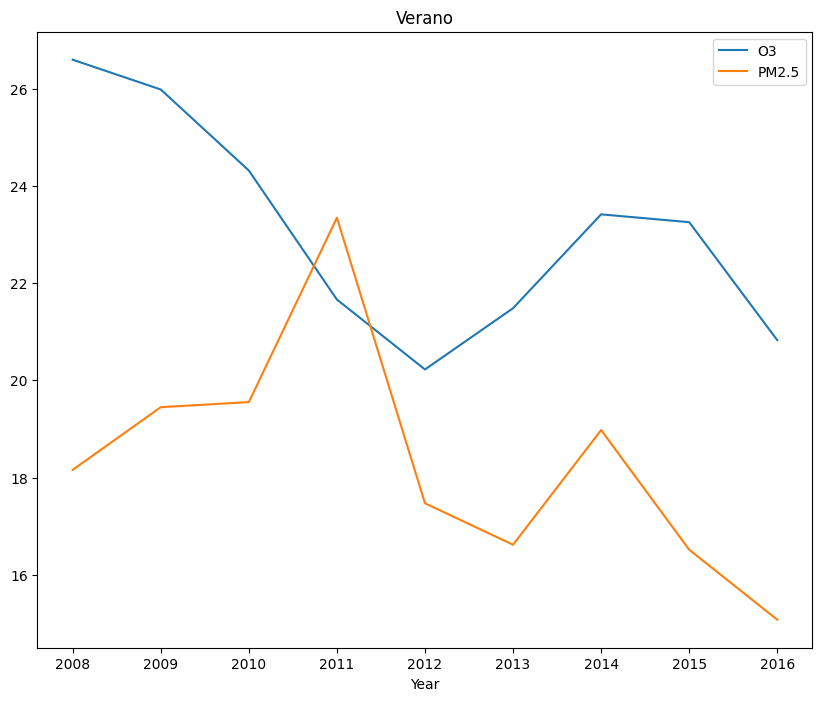

In [38]:
for value in pd.unique(df_null['Estacion'].values):
    sub_df = df_null[df_null['Estacion'] == value]
    sub_df.groupby("Year")[["O3", "PM2.5"]].mean().plot.line(figsize=(10, 8))
    plt.title(value)
    plt.show()

## Misión 6

"Identifique registros atípicos que puedan indicar problemas en la recolección de datos o eventos excepcionales.
Para esto implemente un método basado en el rango intercuartílico (IQR) para identificar valores atípicos
en las columnas de O3 y PM2.5. Cree un nuevo DataFrame que contenga únicamente los registros que fueron
considerados atípicos y analiza si hay alguna relación temporal o estacional en los datos atípicos detectados."

### Tabla Media

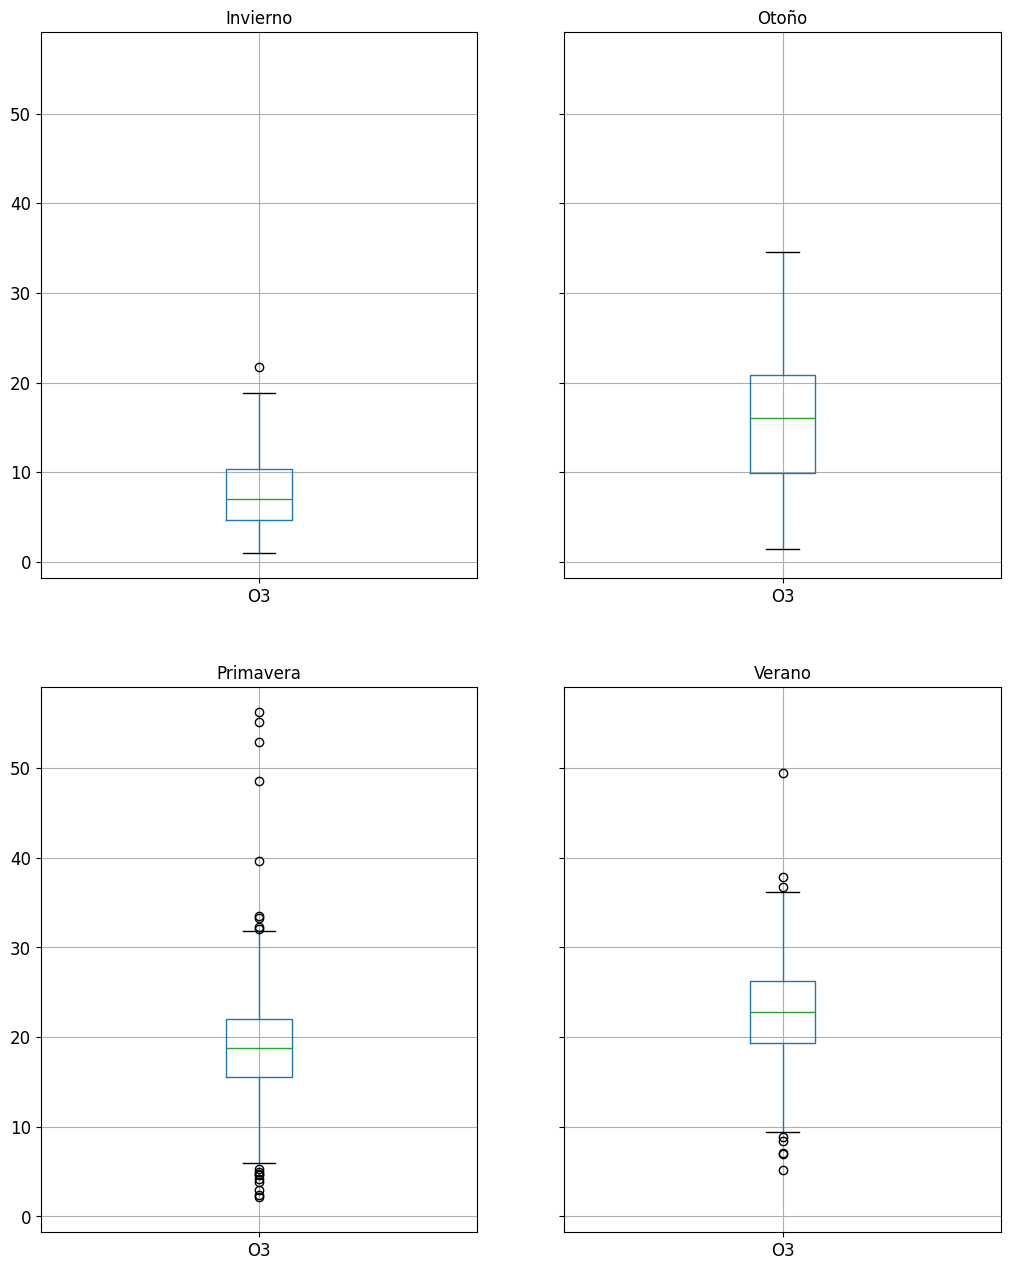

In [39]:
df_media.groupby('Estacion').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

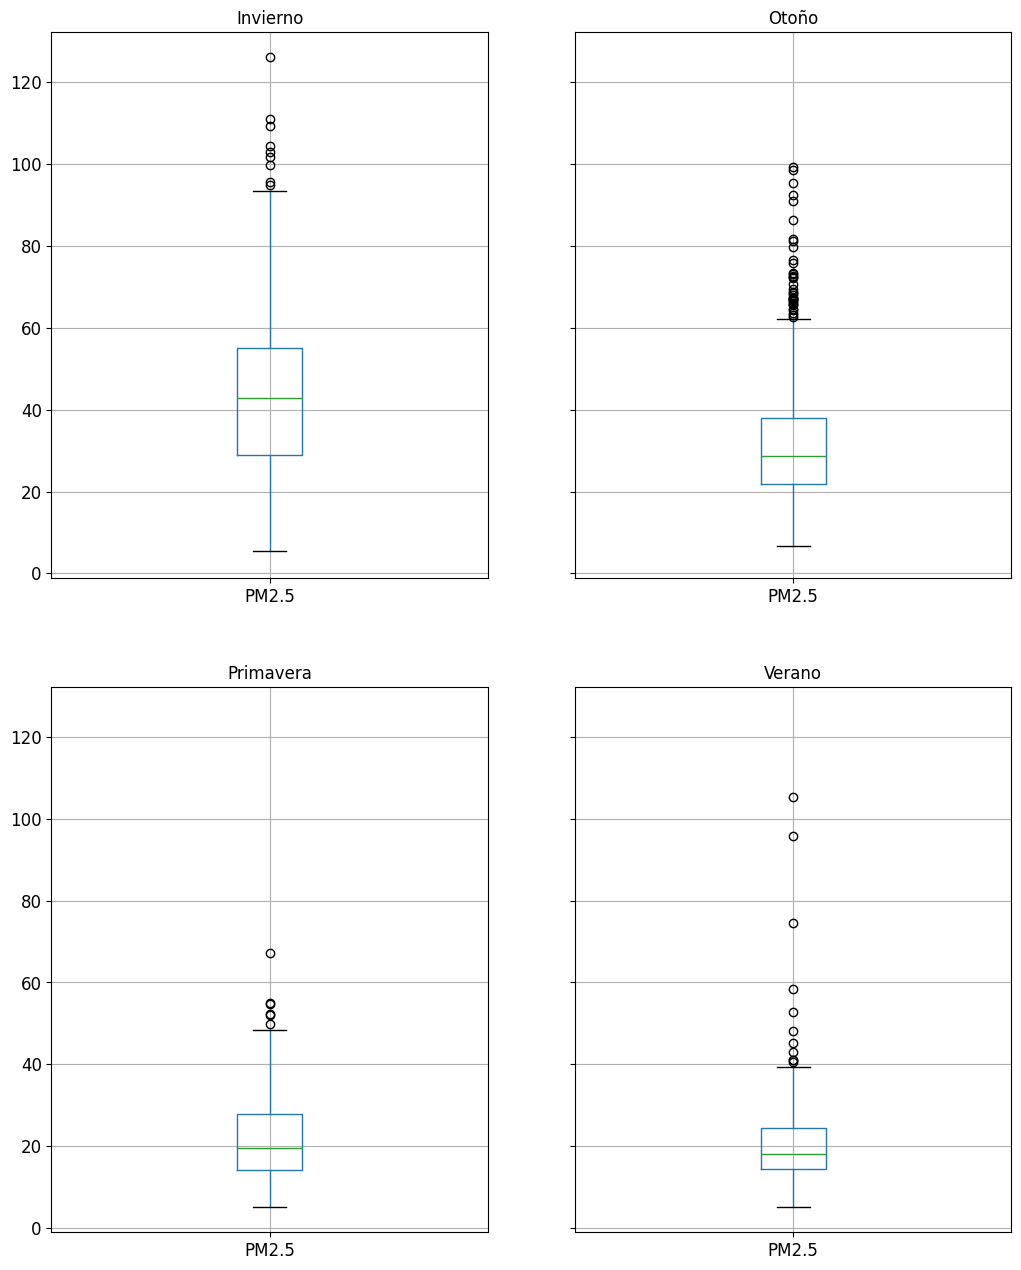

In [40]:
df_media.groupby('Estacion').boxplot(column='PM2.5', fontsize=12, figsize=(12, 16))
plt.show()

In [41]:
df_atipicos = df_media[((df_media['O3'] > 19) & (df_media['Estacion'] == 'Invierno')) |
                         (((df_media['O3'] > 36.5) | (df_media['O3'] < 9.5)) & (df_media['Estacion'] == 'Verano')) |
                         (((df_media['O3'] > 32.5) | (df_media['O3'] < 4.5)) & (df_media['Estacion'] == 'Primavera')) |
                         ((df_media['PM2.5'] < 2.5) & (df_media['Estacion'] == 'Invierno')) |
                         ((df_media['PM2.5'] < 2.05) & (df_media['Estacion'] == 'Otoño')) |
                         (((df_media['PM2.5'] > 4) | (df_media['PM2.5'] < 1.8)) & (df_media['Estacion'] == 'Primavera')) |
                         (((df_media['PM2.5'] < 1.95)| (df_media['PM2.5'] > 3.7)) & (df_media['Estacion'] == 'Verano'))]

In [43]:
conteo = df_atipicos.groupby(['Year', 'Month']).size()

print(conteo)

Year  Month
2008  1        31
      2        29
      9        30
      10       31
      11       30
      12       31
2009  1        31
      2        28
      9        30
      10       31
      11       30
      12       31
2010  1        31
      2        28
      9        30
      10       31
      11       30
      12       31
2011  1        31
      2        28
      9        30
      10       31
      11       30
      12       31
2012  1        31
      2        29
      7         1
      9        30
      10       31
      11       30
      12       31
2013  1        31
      2        28
      9        30
      10       31
      11       30
      12       31
2014  1        31
      2        28
      9        30
      10       31
      11       30
      12       31
2015  1        31
      2        28
      9        30
      10       31
      11       30
      12       31
2016  1        31
      2        29
dtype: int64


### Tabla Null

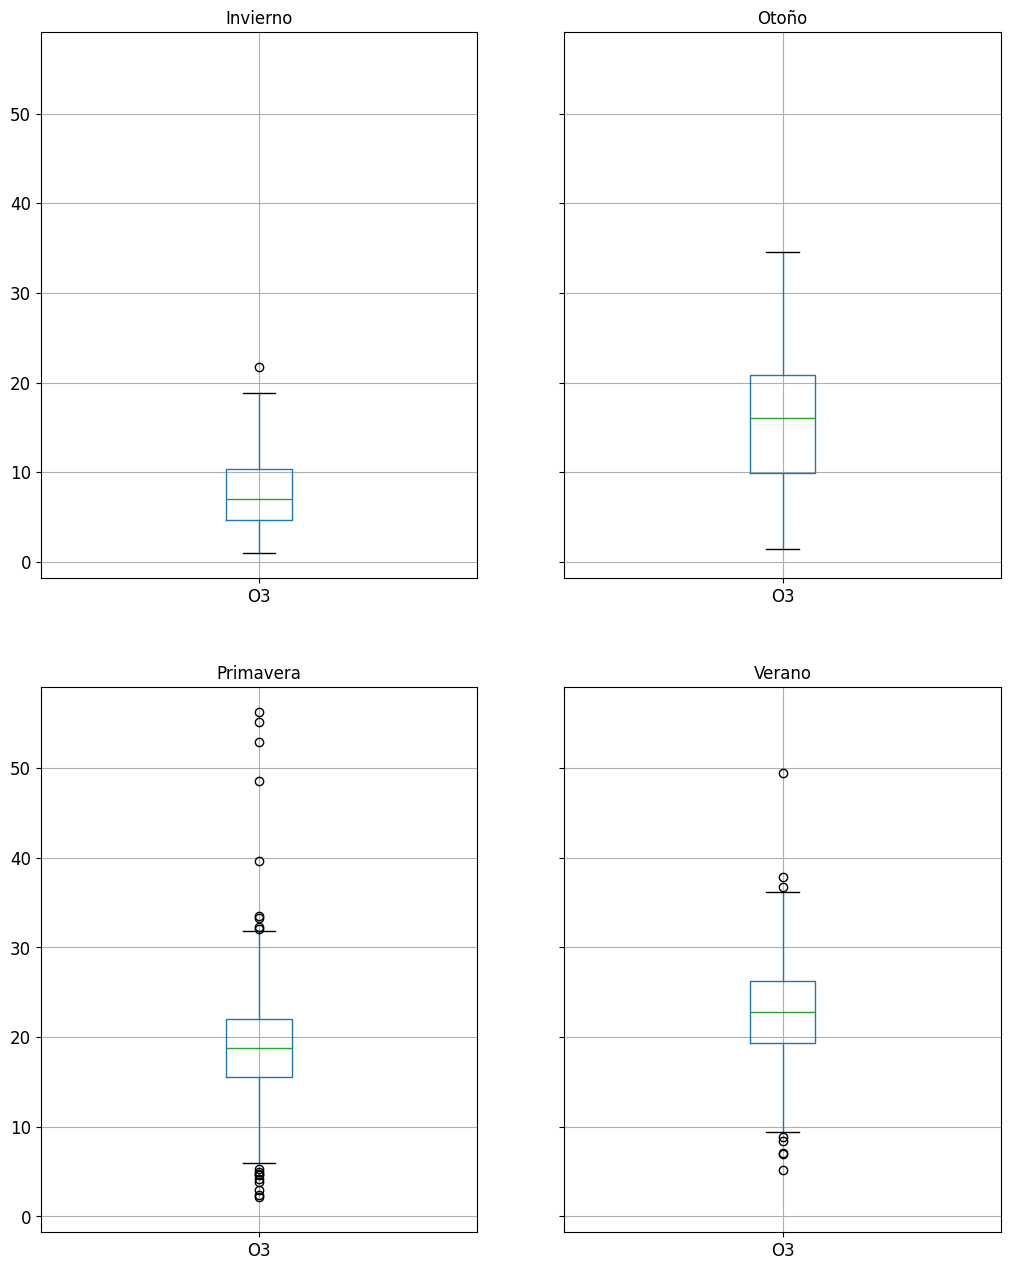

In [44]:
df_media.groupby('Estacion').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

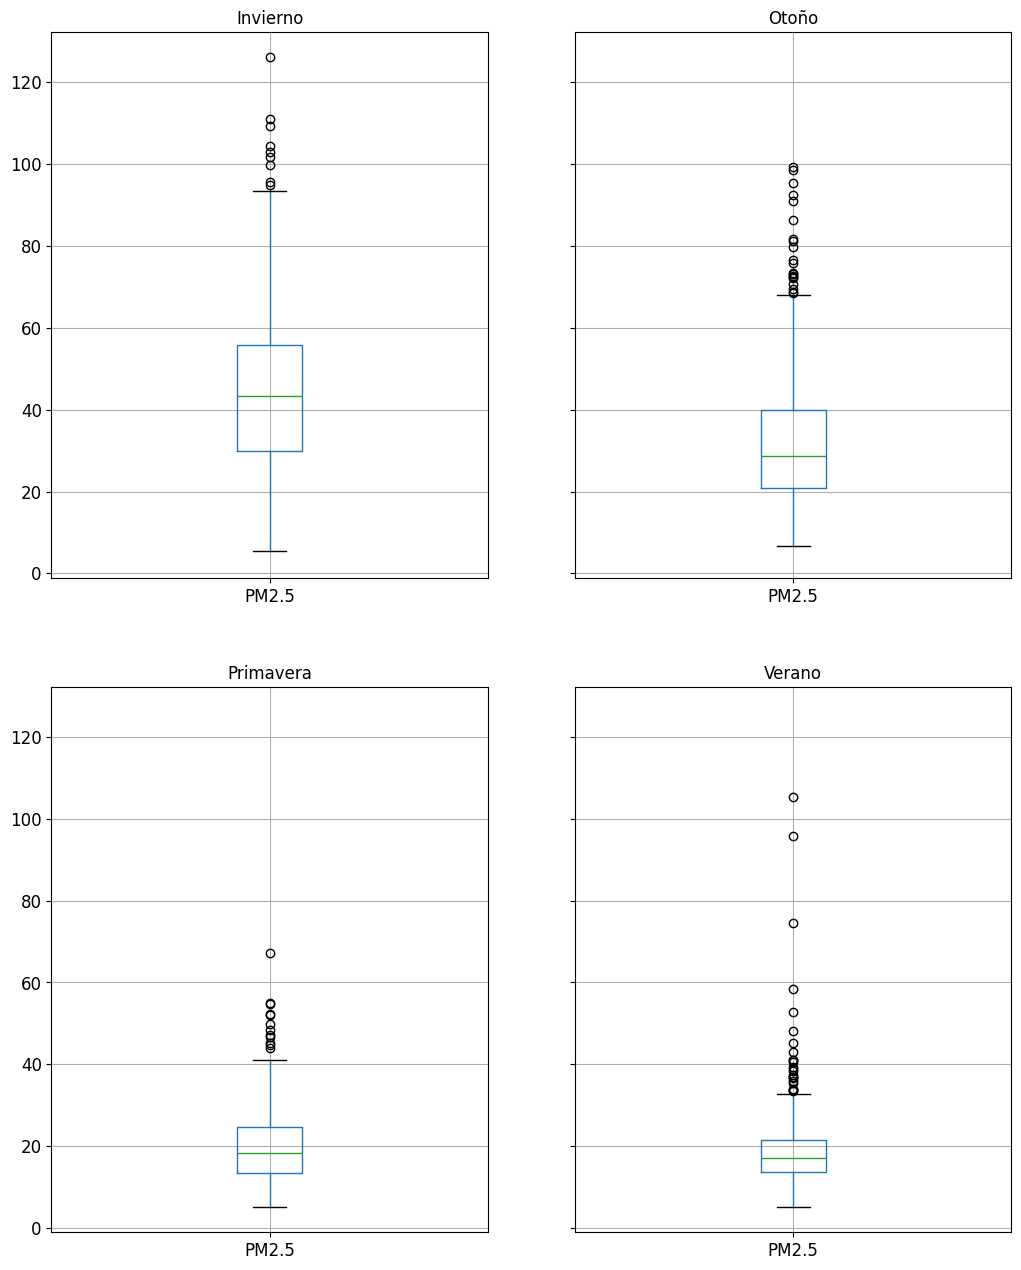

In [45]:
df_null.groupby('Estacion').boxplot(column='PM2.5', fontsize=12, figsize=(12, 16))
plt.show()

In [46]:
df_atipicos = df_null[((df_null['O3'] > 19) & (df_null['Estacion'] == 'Invierno')) |
                         (((df_null['O3'] > 36.5) | (df_null['O3'] < 9.5)) & (df_null['Estacion'] == 'Verano')) |
                         (((df_null['O3'] > 32.5) | (df_null['O3'] < 4.5)) & (df_null['Estacion'] == 'Primavera')) |
                         ((df_null['PM2.5'] < 2.5) & (df_null['Estacion'] == 'Invierno')) |
                         ((df_null['PM2.5'] < 2.05) & (df_null['Estacion'] == 'Otoño')) |
                         (((df_null['PM2.5'] > 4) | (df_null['PM2.5'] < 1.8)) & (df_null['Estacion'] == 'Primavera')) |
                         (((df_null['PM2.5'] < 1.95)| (df_null['PM2.5'] > 3.7)) & (df_null['Estacion'] == 'Verano'))]

In [47]:
conteo = df_atipicos.groupby(['Year', 'Month']).size()

print(conteo)

Year  Month
2008  9        30
      10       31
      11       30
      12       31
2009  1        29
      2        28
      9        30
      10       31
      11       30
      12       27
2010  1        31
      2        26
      9        25
      10       31
      11       30
      12       31
2011  1        30
      2        28
      9        29
      10       31
      11       30
      12       28
2012  1        31
      2        29
      7         1
      9        30
      10       31
      11       30
      12       31
2013  1        31
      2        28
      9         5
      10       15
      11       26
      12       31
2014  1        31
      2        28
      9        22
      10       15
      11        3
      12       17
2015  1        30
      2        28
      9        27
      10       19
      11       29
      12       30
2016  1        27
      2        25
dtype: int64


## Misión 7

"Realice manipulaciones avanzadas de datos para crear nuevas variables y enriquecer el conjunto de datos,
en base a los siguientes pasos:
* Cree una nueva columna que calcule la razón (ratio) entre los niveles de O3 y PM2.5 para cada registro.
* Implemente un algoritmo para detectar y marcar días consecutivos con niveles extremos de O3 o PM2.5
(por encima del percentil 95).
* Genere una nueva columna que clasifique cada registro según el día de la semana y determine si es fin
de semana o día laboral.
* Cree una tabla dinámica (pivot table) que muestre la media de O3 y PM2.5 por mes y por nivel de
riesgo ambiental.
* Utilice groupby y rolling para calcular la media móvil de 7 días para O3 y PM2.5, y añada estas
columnas al conjunto de datos.
* Analice y comenta cómo estas transformaciones enriquecen la comprensión del conjunto de datos."


In [54]:
df = df_null.copy()

In [55]:
df['ratio'] = df['O3'] / df['PM2.5']
df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion,ratio
127,2008,5,7,8.46,48.53,medio,Otoño,0.174325
128,2008,5,8,12.96,56.57,medio,Otoño,0.229097
129,2008,5,9,12.00,54.00,medio,Otoño,0.222222
130,2008,5,10,15.33,69.40,medio,Otoño,0.220893
131,2008,5,11,18.12,91.08,medio,Otoño,0.198946


In [56]:
df['Fecha'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df['Día de la Semana'] = df['Fecha'].dt.dayofweek

tipo_dia = []
for i  in df['Día de la Semana']:
    if i >= 5:
        tipo_dia.append('Fin de Semana')
    else:
        tipo_dia.append('Día Laboral')

df['Tipo de Día'] = tipo_dia
df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion,ratio,Fecha,Día de la Semana,Tipo de Día
127,2008,5,7,8.46,48.53,medio,Otoño,0.174325,2008-05-07,2,Día Laboral
128,2008,5,8,12.96,56.57,medio,Otoño,0.229097,2008-05-08,3,Día Laboral
129,2008,5,9,12.00,54.00,medio,Otoño,0.222222,2008-05-09,4,Día Laboral
130,2008,5,10,15.33,69.40,medio,Otoño,0.220893,2008-05-10,5,Fin de Semana
131,2008,5,11,18.12,91.08,medio,Otoño,0.198946,2008-05-11,6,Fin de Semana


In [57]:
o3_threshold = df['O3'].quantile(0.95)
pm25_threshold = df['PM2.5'].quantile(0.95)

df['Niveles Extremos'] = (df['O3'] > o3_threshold) | (df['PM2.5'] > pm25_threshold)
df = df.sort_values(by='Fecha')
df['Día Consecutivo'] = (df['Niveles Extremos'] & df['Niveles Extremos'].shift(1)).astype(int)

df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion,ratio,Fecha,Día de la Semana,Tipo de Día,Niveles Extremos,Día Consecutivo
127,2008,5,7,8.46,48.53,medio,Otoño,0.174325,2008-05-07,2,Día Laboral,False,0
128,2008,5,8,12.96,56.57,medio,Otoño,0.229097,2008-05-08,3,Día Laboral,False,0
129,2008,5,9,12.00,54.00,medio,Otoño,0.222222,2008-05-09,4,Día Laboral,False,0
130,2008,5,10,15.33,69.40,medio,Otoño,0.220893,2008-05-10,5,Fin de Semana,True,0
131,2008,5,11,18.12,91.08,medio,Otoño,0.198946,2008-05-11,6,Fin de Semana,True,1


In [61]:
pivot_table = pd.pivot_table(
    df,
    values=['O3', 'PM2.5'],
    index='Month',
    columns='Environmental_risk',
    aggfunc='mean'
)

pivot_table.head(10)

O3                                             \
Environmental_risk       Alto       Bajo    extremo      medio      nulo   
Month                                                                      
1                   28.356887        NaN        NaN        NaN  19.30694   
2                         NaN  20.472920  28.683333  24.585056       NaN   
3                         NaN  18.042683  28.500000  23.477815       NaN   
4                         NaN  13.508889        NaN  16.205899       NaN   
5                         NaN   7.564000        NaN   9.380538       NaN   
6                         NaN   8.238235        NaN   6.088698       NaN   
7                         NaN  10.913889        NaN   6.544133       NaN   
8                         NaN  10.574146        NaN   9.435126       NaN   
9                         NaN  15.554167  47.975000  16.434839       NaN   
10                        NaN  16.772712        NaN  20.345233       NaN   

                        PM2.5                                              
Environmental_risk       Alto       Bajo    extremo      medio       nulo  
Month                                                                      
1                   22.833679        NaN        NaN        NaN  14.959851  
2                         NaN  14.361327  16.360556  25.846404        NaN  
3                         NaN  14.728171  17.110000  26.388824        NaN  
4                         NaN  15.458889        NaN  32.021124        NaN  
5                         NaN  13.992667        NaN  45.399641        NaN  
6                         NaN  13.955882        NaN  51.995256        NaN  
7                         NaN  12.557222        NaN  49.882267        NaN  
8                         NaN  14.184634        NaN  39.751859        NaN  
9                         NaN  13.349028  13.500000  30.354032        NaN  
10                        NaN  14.097203        NaN  24.620000        NaN

In [145]:
df['O3_Media'] = df.groupby('Estacion')['O3'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)
df['PM2.5_Media'] = df.groupby('Estacion')['PM2.5'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)

df.head(10)

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion,ratio,Fecha,Día de la Semana,Tipo de Día,Niveles Extremos,Día Consecutivo,O3_Media,PM2.5_Media
127,2008,5,7,8.46,48.53,medio,Otoño,0.174325,2008-05-07,2,Día Laboral,False,0,8.460000,48.530000
128,2008,5,8,12.96,56.57,medio,Otoño,0.229097,2008-05-08,3,Día Laboral,False,0,10.710000,52.550000
129,2008,5,9,12.00,54.00,medio,Otoño,0.222222,2008-05-09,4,Día Laboral,False,0,11.140000,53.033333
130,2008,5,10,15.33,69.40,medio,Otoño,0.220893,2008-05-10,5,Fin de Semana,True,0,12.187500,57.125000
131,2008,5,11,18.12,91.08,medio,Otoño,0.198946,2008-05-11,6,Fin de Semana,True,1,13.374000,63.916000
132,2008,5,12,12.88,55.09,medio,Otoño,0.233799,2008-05-12,0,Día Laboral,False,0,13.291667,62.445000
133,2008,5,13,12.92,59.19,medio,Otoño,0.218280,2008-05-13,1,Día Laboral,False,0,13.238571,61.980000
134,2008,5,14,13.92,42.94,medio,Otoño,0.324173,2008-05-14,2,Día Laboral,False,0,14.018571,61.181429
135,2008,5,15,12.08,81.66,medio,Otoño,0.147930,2008-05-15,3,Día Laboral,True,0,13.892857,64.765714
136,2008,5,16,16.25,72.38,medio,Otoño,0.224510,2008-05-16,4,Día Laboral,True,1,14.500000,67.391429
